In [1]:
import sys, os
sys.path.append("/cluster/home/vogtva/pde-data-gen")
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [2]:
import numpy as np
import pandas as pd
import json
import netCDF4 as nc
import src.db_tools as db_tools
import matplotlib.pyplot as plt
import seaborn as sns
from src.db_tools import (
    get_dataset,
    expand_json_column,
    filter_df,
    filter_dataset,
)
import plotly.express as px
from dotenv import load_dotenv

In [4]:
model = "bruss"
ds_id = "final"
ds, output_dir = get_dataset(model, ds_id, "SCRATCHDIR")
df = ds.df
df["ratio_b_a"] = df["B"] / df["A"]
df["ratio_d"] = df["Dv"] / df["Du"]

In [6]:
df["original_point"]

0        {"A": 1.0, "B": 1.3448275, "Du": 1.0, "Dv": 7.0}
1        {"A": 1.0, "B": 1.3448275, "Du": 1.0, "Dv": 7.0}
2        {"A": 1.0, "B": 1.3448275, "Du": 1.0, "Dv": 7.0}
3        {"A": 1.0, "B": 1.3448275, "Du": 1.0, "Dv": 7.0}
4        {"A": 1.0, "B": 1.3448275, "Du": 1.0, "Dv": 7.0}
                              ...                        
9995    {"A": 1.7105263, "B": 4.895644, "Du": 1.0, "Dv...
9996    {"A": 1.7105263, "B": 4.895644, "Du": 1.0, "Dv...
9997    {"A": 1.7105263, "B": 4.895644, "Du": 1.0, "Dv...
9998    {"A": 1.7105263, "B": 4.895644, "Du": 1.0, "Dv...
9999    {"A": 1.7105263, "B": 4.895644, "Du": 1.0, "Dv...
Name: original_point, Length: 10000, dtype: object

In [8]:
fig = px.scatter_3d(
    df0,
    x="A",
    y="B",
    z=[0] *len(df0),
    opacity=0.7,
)
fig.update_traces(marker_size=2)
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

In [14]:
df['pattern_class'].unique()

array(['dots', 'const', 'labyrinth'], dtype=object)

3.0224304 1.8623686090505176


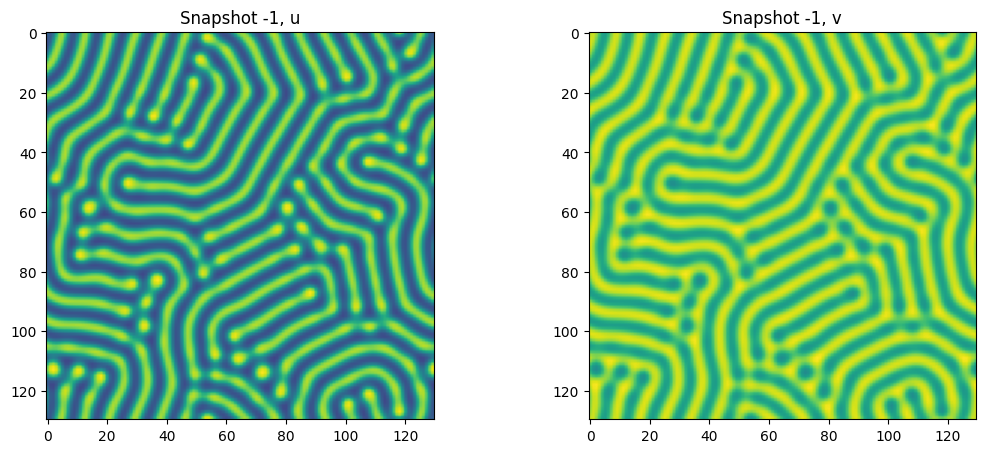

0.5918543 2.6407740891634983


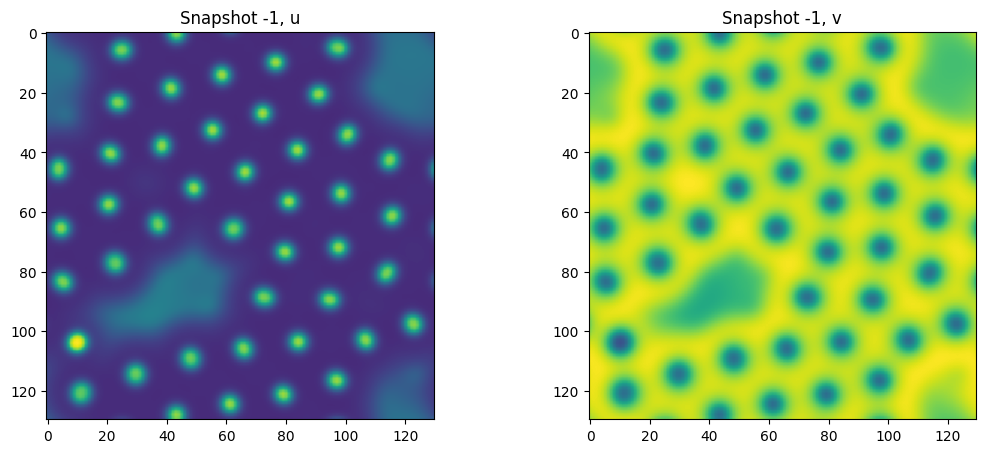

2.9610074 1.8046371650405195


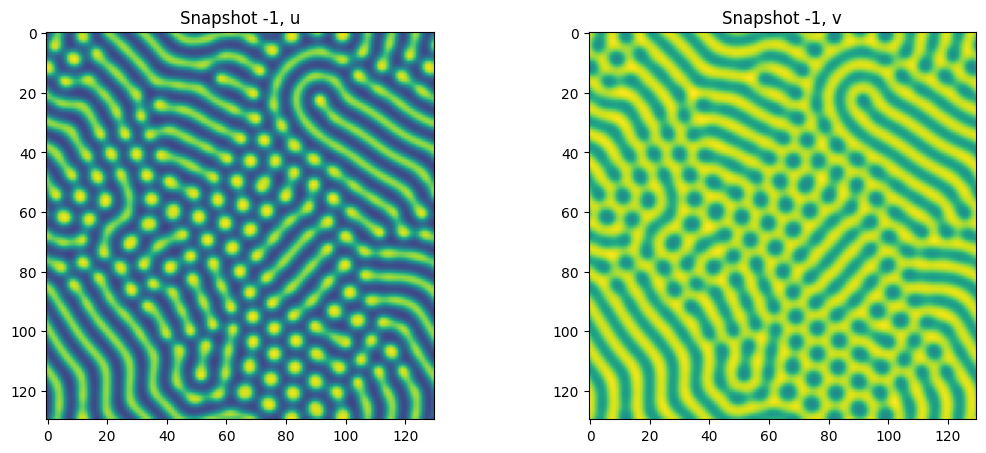

0.571703 2.529646512262486


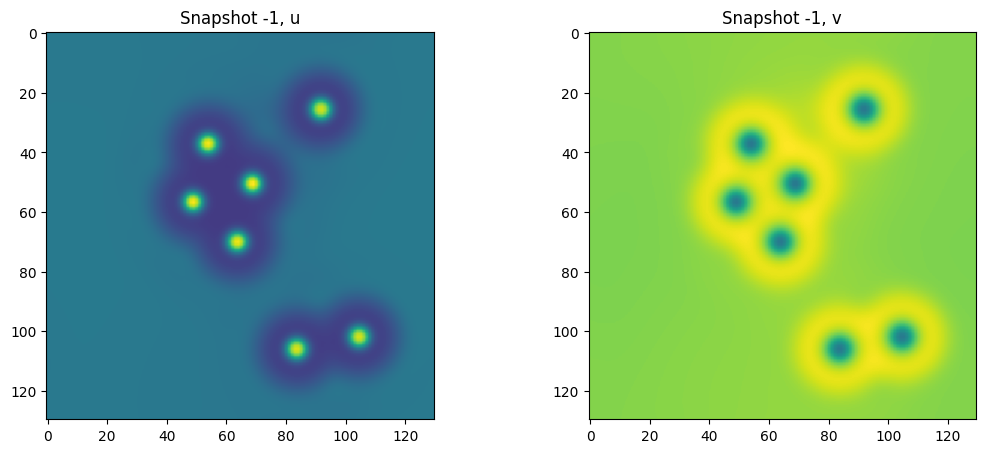

0.68400246 2.3242107930430542


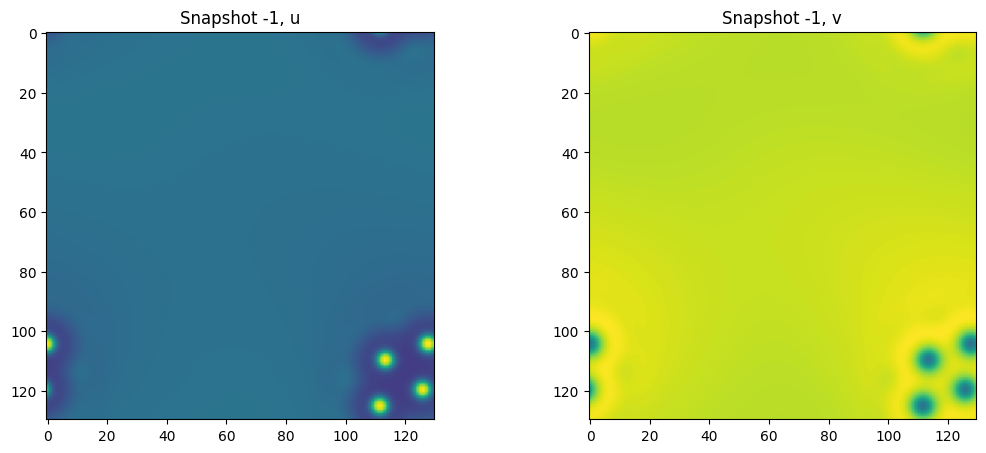

In [16]:
df_sub = df[df.pattern_class == 'labyrinth']
for i, row in df_sub.sample(5).iterrows():
    d = ds.get_data(i)
    print(row["A"], row["ratio_b_a"], flush=True)
    plot(d, 0, np.max(d))
    plt.show()

In [ ]:
indices = [102, 1104, 1814, 2547, 3365, 3466, 6760, 7333, 7698, 9312, 9520, 10686]
df_sel = df.iloc[indices]

<Axes: xlabel='ratio_b_a', ylabel='A'>

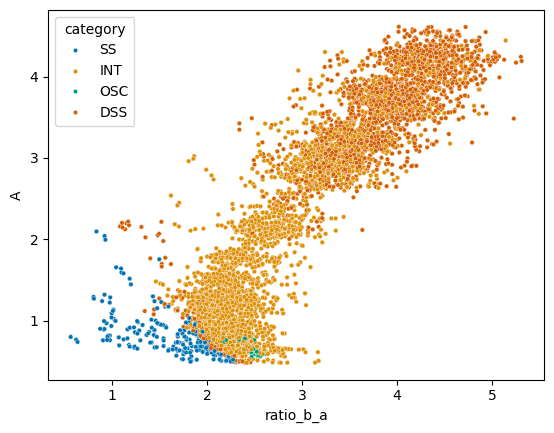

In [ ]:
colorblind_palette = sns.color_palette("colorblind")

# Define a fixed hue mapping
categories = ["SS", "INT", "OSC", "DSS"]
hue_mapping = {cat: colorblind_palette[i] for i, cat in enumerate(categories)}

sns.scatterplot(df, x="ratio_b_a", y="A", hue="category", palette=hue_mapping, hue_order=categories, marker="o", s=10)
